In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

np.random.seed(30)

Part 1

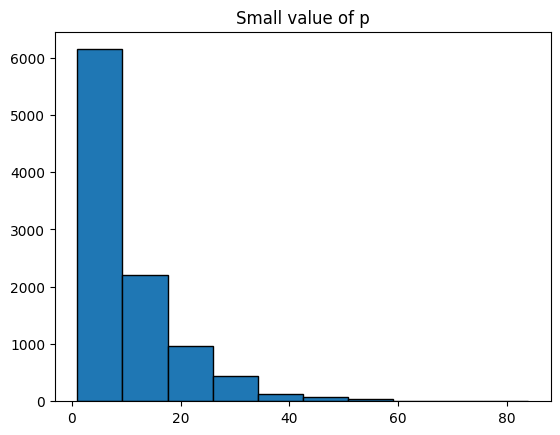

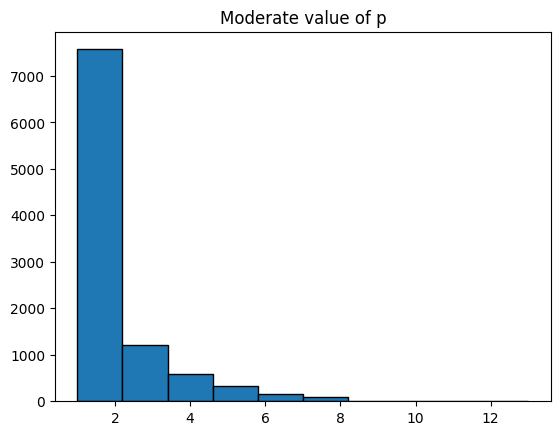

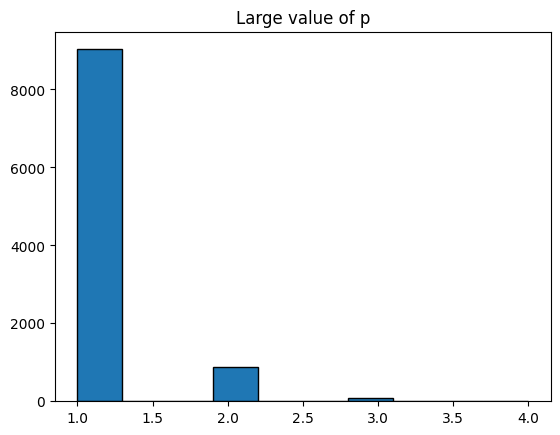

In [ ]:
def geometric(p
    U = np.ranom.uniform(0.0,1.0)
    X = np.floor(np.log(U) / np.log(1-p)) + 1 
    return X  uvuv  jbj  #

p = 0.1
X = [geometric(p) for _ in range(10000)]
plt.hist(X, edgecolor='black')
plt.title('Small value of p')
plt.show()

p = 0.5
X = [geometric(p) for _ in range(10000)]
plt.hist(X, edgecolor='black')
plt.title('Moderate value of p')
plt.show()

p = 0.9
X = [geometric(p) for _ in range(10000)]
plt.hist(X, edgecolor='black')
plt.title('Large value of p')
plt.show()

Part 2

In [4]:
x = np.array([1, 2, 3, 4, 5, 6])
p = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

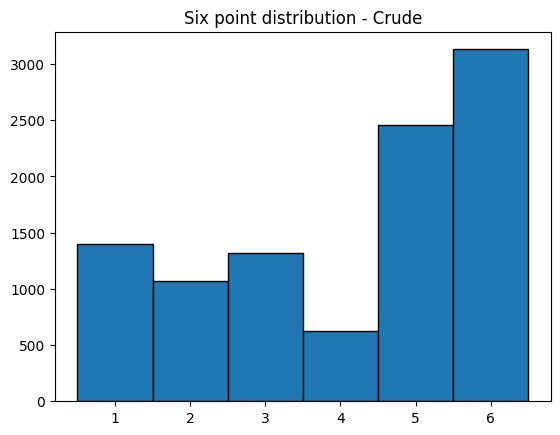

In [5]:
def six_point_crude(x, p):
    U = np.random.uniform(0, 1)
    cdf = np.cumsum(p)
    for i in range(len(x)):
        if U <= cdf[i]:
            return x[i]

observations = [six_point_crude(x, p) for _ in range(10000)]
plt.hist(observations, bins=np.arange(0.5, 7.5, 1), edgecolor='black')
plt.xticks(x)
plt.title('Six point distribution - Crude')
plt.show()

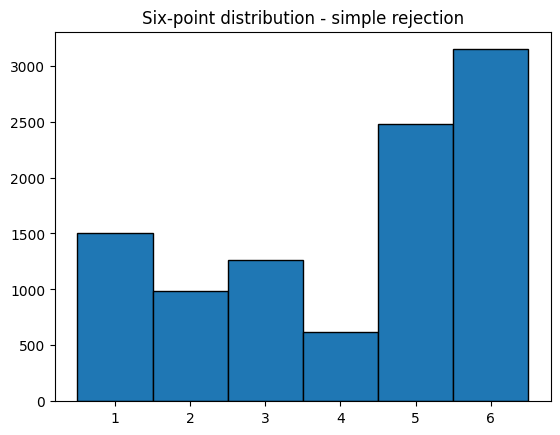

In [6]:
def six_point_rejection(x,p):
    c = np.max(p) + 0.1
    k = len(x)

    while True:
        U1 = np.random.uniform(0,1)
        U2 = np.random.uniform(0,1)
        I = int(np.floor(k*U1))
        if U2 <= p[I]/c:
            return x[I]

observations = [six_point_rejection(x,p) for _ in range(10000)]
plt.hist(observations, bins=np.arange(0.5, 7.5, 1), edgecolor='black')
plt.xticks(x)
plt.title('Six-point distribution - simple rejection')
plt.show()

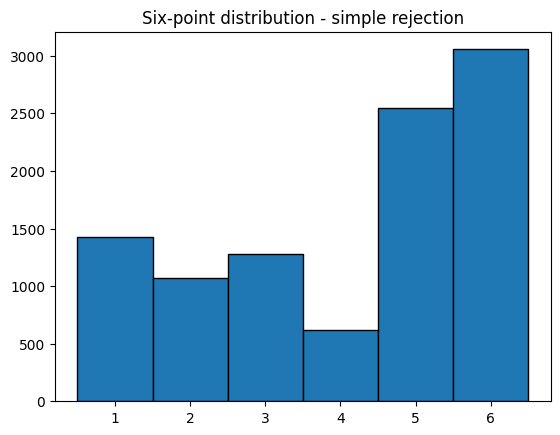

In [ ]:
def generate_F_L(p, k):
    eps = 1e-12

    L = np.arange(k)
    F = k * p

    G = list(np.where(F >= 1)[0])
    S = list(np.where(F <= 1)[0])

    while len(S) > 0:
        i = G[0]
        j = S[0]

        L[j] = i
        F[i] = F[i] - (1 - F[j])

        if F[i] < 1 - eps:
            G.pop(0)
            S.append(i)

        S.pop(0)


    return F, L

def six_point_alias(x,p):
    k = len(p)
    F, L = generate_F_L(p, k)
    
    while True:
        U1 = np.random.uniform(0,1)
        U2 = np.random.uniform(0,1)
        I = int(np.floor(k*U1)) + 1
        if U2 <= F[I-1]:
            return x[I-1]
        else:
            return x[L[I-1]]

observations = [six_point_alias(x,p) for _ in range(10000)]
plt.hist(observations, bins=np.arange(0.5, 7.5, 1), edgecolor='black')
plt.xticks(x)
plt.title('Six-point distribution - alis method')
plt.show()

    

Part 3